# Monte Carlo Analysis

This notebook processes the results from multiple simulation runs. It scans all merged simulation outputs, extracts key metrics, and provides statistical summaries and visualizations.

**Key Analyses**
- Extracts peak adult population and timing from each run
- Computes statistical summaries (mean, median, std, 95% CI)
- Generates histograms and box plots of peak populations
- Shows time series from representative runs
- Produces a complete report with all findings

**Assumptions**
- Simulation outputs follow the naming pattern: `merged_snapshots_*.csv`
- Each file contains adult population data across ticks
- Ticks represent 15-minute time steps (96 ticks per day)

In [1]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, t
from scipy.interpolate import RegularGridInterpolator
from sklearn.neighbors import KernelDensity
import warnings
warnings.filterwarnings('ignore')

# ======================================================================
# CONFIGURATION – EDIT THESE PATHS
# ======================================================================
MONTE_CARLO_DIR = "/mnt/monadworld/projects/phd/monte_carlo_results"
CHUNKSIZE = 100000
TICKS_PER_RUN = 17280  # Total ticks per simulation

# Output paths
OUTPUT_CSV = os.path.join(MONTE_CARLO_DIR, 'monte_carlo_peak_analysis.csv')
OUTPUT_PEAK_PNG = os.path.join(MONTE_CARLO_DIR, 'monte_carlo_peak_analysis.png')
OUTPUT_TIMESERIES_PNG = os.path.join(MONTE_CARLO_DIR, 'monte_carlo_time_series.png')
OUTPUT_REPORT = os.path.join(MONTE_CARLO_DIR, 'monte_carlo_complete_report.txt')

os.makedirs(MONTE_CARLO_DIR, exist_ok=True)

## 1. Core Analysis Functions

In [2]:
# ----------------------------------------------------------------------
# Helper Functions
# ----------------------------------------------------------------------
def find_merged_files(base_dir):
    """Find all merged simulation output files in the Monte Carlo directory."""
    pattern = os.path.join(base_dir, "seed_*", "merged_*.csv")
    files = glob.glob(pattern)
    print(f"Found {len(files)} merged files")
    return files


def analyze_tick_distribution(filepath, chunksize=CHUNKSIZE):
    """
    Analyze adult distribution across all ticks in a run.
    Returns the tick with maximum adults and the peak adult count.
    """
    try:
        print(f"  Analyzing: {os.path.basename(filepath)}")
        
        # Track adults by tick
        adult_by_tick = {}
        total_adults = 0
        max_tick = 0
        
        # Process file in chunks
        for chunk in pd.read_csv(filepath, 
                                 usecols=['TickCount', 'AgentType', 'Stage'], 
                                 chunksize=chunksize, 
                                 low_memory=False):
            
            # Filter for adult LivingAgents
            mask = (chunk['AgentType'] == 'LivingAgent') & (chunk['Stage'] == 'ADULT')
            adults = chunk[mask]
            
            if not adults.empty:
                # Count adults per tick
                tick_counts = adults['TickCount'].value_counts()
                for tick, count in tick_counts.items():
                    adult_by_tick[tick] = adult_by_tick.get(tick, 0) + count
                    total_adults += count
                    if tick > max_tick:
                        max_tick = tick
        
        # Find peak tick (maximum adults)
        if adult_by_tick:
            peak_tick = max(adult_by_tick, key=adult_by_tick.get)
            peak_adults = adult_by_tick[peak_tick]
            
            # Get adults at final tick
            final_adults = adult_by_tick.get(max_tick, 0)
            
            # Get adults at tick 100 (early stage) if available
            early_adults = adult_by_tick.get(100, 0)
            
            print(f"  Total adults across all ticks: {total_adults:,}")
            print(f"  Peak tick: {peak_tick} with {peak_adults:,} adults")
            print(f"  Final tick ({max_tick}): {final_adults:,} adults")
            if early_adults > 0:
                print(f"  Tick 100: {early_adults:,} adults")
            
            return {
                'file': os.path.basename(filepath),
                'peak_tick': peak_tick,
                'peak_adults': peak_adults,
                'final_tick': max_tick,
                'final_adults': final_adults,
                'early_adults': early_adults,
                'total_adults': total_adults,
                'ticks_with_adults': len(adult_by_tick)
            }
        else:
            print("  No adults found in this file!")
            return None
            
    except Exception as e:
        print(f"  Error: {e}")
        return None


def get_time_series(filepath, chunksize=CHUNKSIZE):
    """
    Get the full adult population time series for a run.
    """
    try:
        adult_series = {}
        
        for chunk in pd.read_csv(filepath, 
                                 usecols=['TickCount', 'AgentType', 'Stage'], 
                                 chunksize=chunksize, 
                                 low_memory=False):
            
            mask = (chunk['AgentType'] == 'LivingAgent') & (chunk['Stage'] == 'ADULT')
            adults = chunk[mask]
            
            if not adults.empty:
                tick_counts = adults['TickCount'].value_counts()
                for tick, count in tick_counts.items():
                    adult_series[tick] = adult_series.get(tick, 0) + count
        
        if adult_series:
            df_series = pd.DataFrame({
                'tick': sorted(adult_series.keys()),
                'adults': [adult_series[t] for t in sorted(adult_series.keys())]
            })
            return df_series
        else:
            return pd.DataFrame(columns=['tick', 'adults'])
            
    except Exception as e:
        print(f"  Error getting time series: {e}")
        return pd.DataFrame(columns=['tick', 'adults'])

## 2. Run Analysis

Process all Monte Carlo output files and extract key metrics.

In [3]:
print("="*60)
print("MONTE CARLO ANALYSIS - PEAK ADULT POPULATION")
print("="*60)

merged_files = find_merged_files(MONTE_CARLO_DIR)

results = []
for i, filepath in enumerate(merged_files):
    print(f"\n[{i+1}/{len(merged_files)}] {os.path.basename(filepath)}")
    result = analyze_tick_distribution(filepath)
    if result:
        results.append(result)

if not results:
    raise RuntimeError("❌ No results were produced!")

df_results = pd.DataFrame(results)
df_results.to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ Results saved to: {OUTPUT_CSV}")

MONTE CARLO ANALYSIS - PEAK ADULT POPULATION
Found 30 merged files

[1/30] merged_snapshots_20260826_103341.csv
  Analyzing: merged_snapshots_20260826_103341.csv
  Total adults across all ticks: 71,985
  Peak tick: 100 with 6,132 adults
  Final tick (4800): 1 adults
  Tick 100: 6,132 adults

[2/30] merged_snapshots_20260826_111202.csv
  Analyzing: merged_snapshots_20260826_111202.csv
  Total adults across all ticks: 157,208
  Peak tick: 100 with 8,011 adults
  Final tick (6100): 1 adults
  Tick 100: 8,011 adults

[3/30] merged_snapshots_20260826_115156.csv
  Analyzing: merged_snapshots_20260826_115156.csv
  Total adults across all ticks: 188,309
  Peak tick: 100 with 7,872 adults
  Final tick (7400): 2 adults
  Tick 100: 7,872 adults

[4/30] merged_snapshots_20260826_122202.csv
  Analyzing: merged_snapshots_20260826_122202.csv
  Total adults across all ticks: 51,713
  Peak tick: 100 with 4,863 adults
  Final tick (5300): 1 adults
  Tick 100: 4,863 adults

[5/30] merged_snapshots_202608

## 3. Summary Statistics

In [4]:
def compute_statistics(df_results):
    n = len(df_results)
    
    # Peak adults
    peak_mean = df_results['peak_adults'].mean()
    peak_std = df_results['peak_adults'].std()
    peak_median = df_results['peak_adults'].median()
    peak_min = df_results['peak_adults'].min()
    peak_max = df_results['peak_adults'].max()
    peak_range = peak_max - peak_min
    
    # 95% CI
    se = peak_std / np.sqrt(n)
    ci_low, ci_high = t.interval(0.95, n-1, loc=peak_mean, scale=se)
    
    # Peak tick
    tick_mean = df_results['peak_tick'].mean()
    tick_median = df_results['peak_tick'].median()
    tick_min = df_results['peak_tick'].min()
    tick_max = df_results['peak_tick'].max()
    
    # Final adults
    final_mean = df_results['final_adults'].mean()
    final_median = df_results['final_adults'].median()
    zero_final = (df_results['final_adults'] == 0).sum()
    
    # Early adults
    early_mean = df_results['early_adults'].mean()
    early_median = df_results['early_adults'].median()
    zero_early = (df_results['early_adults'] == 0).sum()
    
    stats = {
        'n': n,
        'peak_mean': peak_mean,
        'peak_std': peak_std,
        'peak_median': peak_median,
        'peak_min': peak_min,
        'peak_max': peak_max,
        'peak_range': peak_range,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'tick_mean': tick_mean,
        'tick_median': tick_median,
        'tick_min': tick_min,
        'tick_max': tick_max,
        'final_mean': final_mean,
        'final_median': final_median,
        'zero_final': zero_final,
        'early_mean': early_mean,
        'early_median': early_median,
        'zero_early': zero_early,
    }
    return stats

stats = compute_statistics(df_results)

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print(f"\n📊 Peak Adult Population (maximum adults at any tick):")
print(f"  Mean: {stats['peak_mean']:,.0f} ± {stats['peak_std']:,.0f}")
print(f"  Median: {stats['peak_median']:,.0f}")
print(f"  95% CI: [{stats['ci_low']:,.0f}, {stats['ci_high']:,.0f}]")
print(f"  Min: {stats['peak_min']:,.0f}")
print(f"  Max: {stats['peak_max']:,.0f}")
print(f"  Range: {stats['peak_range']:,.0f}")

print(f"\n📈 Peak Timing:")
print(f"  Mean peak tick: {stats['tick_mean']:.0f}")
print(f"  Median peak tick: {stats['tick_median']:.0f}")
print(f"  Range: {stats['tick_min']:.0f} - {stats['tick_max']:.0f}")

print(f"\n📉 Population Stages:")
print(f"  Early (tick 100): {stats['early_mean']:,.0f} adults")
print(f"  Peak: {stats['peak_mean']:,.0f} adults")
print(f"  Final: {stats['final_mean']:,.0f} adults")


SUMMARY STATISTICS

📊 Peak Adult Population (maximum adults at any tick):
  Mean: 6,005 ± 1,754
  Median: 6,096
  95% CI: [5,350, 6,660]
  Min: 2,978
  Max: 8,936
  Range: 5,958

📈 Peak Timing:
  Mean peak tick: 100
  Median peak tick: 100
  Range: 100 - 100

📉 Population Stages:
  Early (tick 100): 6,005 adults
  Peak: 6,005 adults
  Final: 1 adults


## 4. Visualizations

Generate plots showing the distribution of peak populations, timing, and example time series.

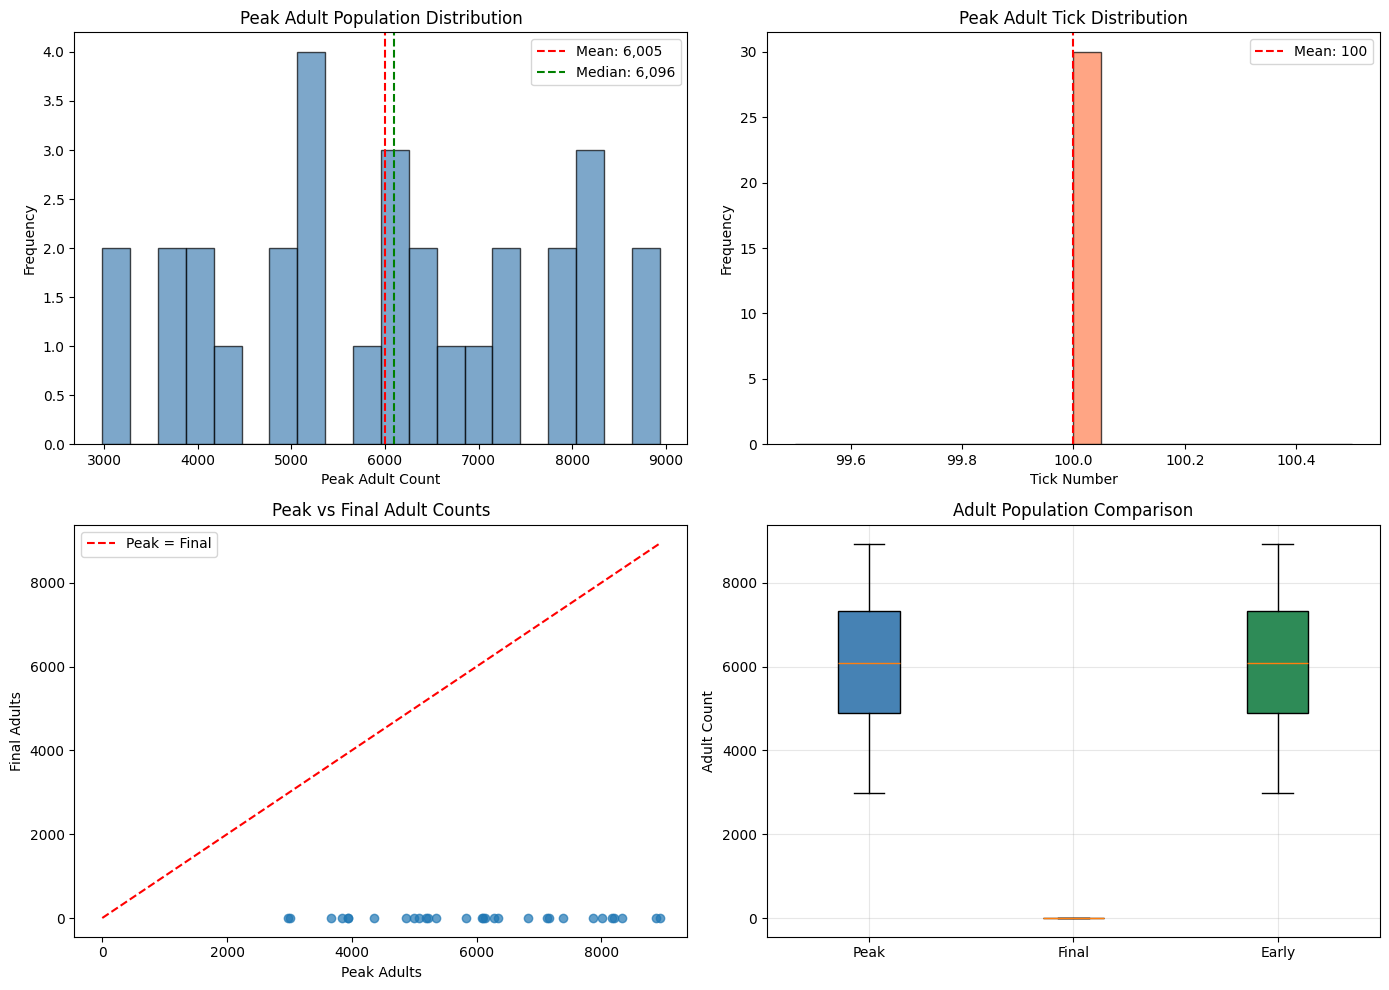

✅ Figure saved to: /mnt/monadworld/projects/phd/monte_carlo_results/monte_carlo_peak_analysis.png


In [5]:
def plot_peak_analysis(df_results, stats, output_path):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Peak adult distribution
    ax = axes[0, 0]
    ax.hist(df_results['peak_adults'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(stats['peak_mean'], color='red', linestyle='--', label=f'Mean: {stats["peak_mean"]:,.0f}')
    ax.axvline(stats['peak_median'], color='green', linestyle='--', label=f'Median: {stats["peak_median"]:,.0f}')
    ax.set_xlabel('Peak Adult Count')
    ax.set_ylabel('Frequency')
    ax.set_title('Peak Adult Population Distribution')
    ax.legend()
    
    # 2. Peak tick distribution
    ax = axes[0, 1]
    ax.hist(df_results['peak_tick'], bins=20, edgecolor='black', alpha=0.7, color='coral')
    ax.axvline(stats['tick_mean'], color='red', linestyle='--', 
               label=f'Mean: {stats["tick_mean"]:.0f}')
    ax.set_xlabel('Tick Number')
    ax.set_ylabel('Frequency')
    ax.set_title('Peak Adult Tick Distribution')
    ax.legend()
    
    # 3. Peak vs Final adults
    ax = axes[1, 0]
    ax.scatter(df_results['peak_adults'], df_results['final_adults'], alpha=0.7)
    ax.plot([0, df_results['peak_adults'].max()], [0, df_results['peak_adults'].max()], 
            'r--', label='Peak = Final')
    ax.set_xlabel('Peak Adults')
    ax.set_ylabel('Final Adults')
    ax.set_title('Peak vs Final Adult Counts')
    ax.legend()
    
    # 4. Box plot comparison
    ax = axes[1, 1]
    data_to_plot = [df_results['peak_adults'], df_results['final_adults'], df_results['early_adults']]
    bp = ax.boxplot(data_to_plot, labels=['Peak', 'Final', 'Early'], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['steelblue', 'coral', 'seagreen']):
        patch.set_facecolor(color)
    ax.set_ylabel('Adult Count')
    ax.set_title('Adult Population Comparison')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_peak_analysis(df_results, stats, OUTPUT_PEAK_PNG)
print(f"✅ Figure saved to: {OUTPUT_PEAK_PNG}")


TIME SERIES ANALYSIS


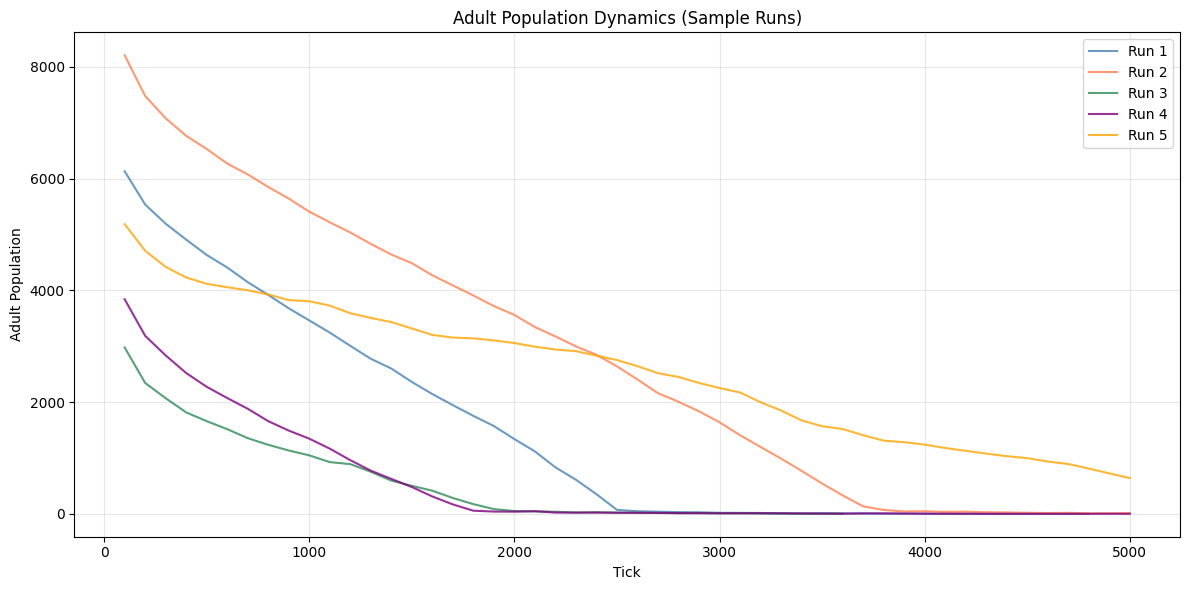

✅ Time series figure saved to: /mnt/monadworld/projects/phd/monte_carlo_results/monte_carlo_time_series.png


In [6]:
def plot_time_series(merged_files, output_path, max_ticks=5000, n_samples=5):
    """
    Plot time series for a sample of runs.
    """
    print("\n" + "="*60)
    print("TIME SERIES ANALYSIS")
    print("="*60)
    
    # Select representative runs
    n_files = len(merged_files)
    if n_files <= n_samples:
        sample_indices = list(range(n_files))
    else:
        step = n_files // n_samples
        sample_indices = list(range(0, n_files, step))[:n_samples]
    
    sample_files = [merged_files[i] for i in sample_indices]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['steelblue', 'coral', 'seagreen', 'purple', 'orange']
    
    for i, filepath in enumerate(sample_files):
        df_series = get_time_series(filepath)
        if not df_series.empty:
            df_plot = df_series[df_series['tick'] <= max_ticks]
            if not df_plot.empty:
                ax.plot(df_plot['tick'], df_plot['adults'], 
                       label=f'Run {i+1}', color=colors[i % len(colors)], 
                       linewidth=1.5, alpha=0.8)
    
    ax.set_xlabel('Tick')
    ax.set_ylabel('Adult Population')
    ax.set_title('Adult Population Dynamics (Sample Runs)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Time series figure saved to: {output_path}")

plot_time_series(merged_files, OUTPUT_TIMESERIES_PNG)

## 5. Report Generation

Generate a complete text report with all findings.

In [ ]:
def generate_report(df_results, stats, output_path):
    with open(output_path, 'w') as f:
        f.write("="*70 + "\n")
        f.write("MONTE CARLO SIMULATION - COMPLETE REPORT\n")
        f.write("="*70 + "\n\n")
        
        f.write(f"Total runs: {stats['n']}\n")
        f.write(f"Ticks per run: {TICKS_PER_RUN}\n\n")
        
        f.write("PEAK ADULT POPULATION\n")
        f.write("-"*40 + "\n")
        f.write(f"  Mean: {stats['peak_mean']:,.0f} ± {stats['peak_std']:,.0f}\n")
        f.write(f"  Median: {stats['peak_median']:,.0f}\n")
        f.write(f"  95% CI: [{stats['ci_low']:,.0f}, {stats['ci_high']:,.0f}]\n")
        f.write(f"  Min: {stats['peak_min']:,.0f}\n")
        f.write(f"  Max: {stats['peak_max']:,.0f}\n")
        f.write(f"  Range: {stats['peak_range']:,.0f}\n\n")
        
        f.write("PEAK TICK DISTRIBUTION\n")
        f.write("-"*40 + "\n")
        f.write(f"  Mean: {stats['tick_mean']:.0f}\n")
        f.write(f"  Median: {stats['tick_median']:.0f}\n")
        f.write(f"  Min: {stats['tick_min']:.0f}\n")
        f.write(f"  Max: {stats['tick_max']:.0f}\n\n")
        
        f.write("FINAL TICK ADULTS\n")
        f.write("-"*40 + "\n")
        f.write(f"  Mean: {stats['final_mean']:,.0f}\n")
        f.write(f"  Median: {stats['final_median']:,.0f}\n")
        f.write(f"  Runs with 0 final adults: {stats['zero_final']}\n\n")
        
        f.write("EARLY STAGE ADULTS (Tick 100)\n")
        f.write("-"*40 + "\n")
        f.write(f"  Mean: {stats['early_mean']:,.0f}\n")
        f.write(f"  Median: {stats['early_median']:,.0f}\n")
        f.write(f"  Runs with 0 early adults: {stats['zero_early']}\n\n")
        
        f.write("="*70 + "\n")
        f.write(f"Report generated: {pd.Timestamp.now()}\n")
        f.write(f"Results directory: {MONTE_CARLO_DIR}\n")
    
    print(f"✅ Complete report saved to: {output_path}")

generate_report(df_results, stats, OUTPUT_REPORT)

## 6. Publication Summary

Print a concise summary suitable for publications.

In [ ]:
def print_publication_summary(stats):
    print("\n" + "="*70)
    print("MONTE CARLO SIMULATION - PUBLICATION SUMMARY")
    print("="*70)
    print(f"\n📊 Peak Adult Population (n={stats['n']} runs):")
    print(f"  Mean ± SD: {stats['peak_mean']:,.0f} ± {stats['peak_std']:,.0f}")
    print(f"  Median: {stats['peak_median']:,.0f}")
    print(f"  95% CI: [{stats['ci_low']:,.0f}, {stats['ci_high']:,.0f}]")
    print(f"  Range: {stats['peak_min']:,.0f} - {stats['peak_max']:,.0f}")
    print(f"\n📈 Peak Timing:")
    print(f"  Mean peak tick: {stats['tick_mean']:.0f}")
    print(f"  Median peak tick: {stats['tick_median']:.0f}")
    print(f"\n📉 Population Stages:")
    print(f"  Early (tick 100): {stats['early_mean']:,.0f} adults")
    print(f"  Peak: {stats['peak_mean']:,.0f} adults")
    print(f"  Final: {stats['final_mean']:,.0f} adults")

print_publication_summary(stats)

print("\n" + "="*60)
print("✅ MONTE CARLO ANALYSIS COMPLETE")
print("="*60)
print(f"\nResults saved to: {MONTE_CARLO_DIR}")
print(f"  - {os.path.basename(OUTPUT_CSV)} (peak data)")
print(f"  - {os.path.basename(OUTPUT_PEAK_PNG)} (visualizations)")
print(f"  - {os.path.basename(OUTPUT_TIMESERIES_PNG)} (population dynamics)")
print(f"  - {os.path.basename(OUTPUT_REPORT)} (full report)")